EXP 8 – SCENARIO 1: APRIORI

In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
import networkx as nx


# Load Dataset
data = pd.read_csv("Groceries_dataset.csv")

# Display sample
print(data.head())

# Convert to Transaction List
transactions = data.groupby('Member_number')['itemDescription'].apply(list).values

C:\Users\HP\AppData\Roaming\Python\Python313\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.10.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


   Member_number        Date   itemDescription
0           1808  21-07-2015    tropical fruit
1           2552  05-01-2015        whole milk
2           2300  19-09-2015         pip fruit
3           1187  12-12-2015  other vegetables
4           3037  01-02-2015        whole milk


In [2]:
# One-Hot Encoding
te = TransactionEncoder()
te_data = te.fit(transactions).transform(transactions)
df = pd.DataFrame(te_data, columns=te.columns_)

# Apply Apriori
frequent_itemsets = apriori(df, min_support=0.02, use_colnames=True)

print("\nFrequent Itemsets:")
print(frequent_itemsets.head())


Frequent Itemsets:
    support                    itemsets
0  0.078502       frozenset({UHT-milk})
1  0.031042  frozenset({baking powder})
2  0.119548           frozenset({beef})
3  0.079785        frozenset({berries})
4  0.062083      frozenset({beverages})


In [3]:
# Generate Association Rules
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)

# Filter using Lift
rules = rules[rules['lift'] > 1]

print("\nAssociation Rules:")
print(rules.head())


Association Rules:
             antecedents                    consequents  antecedent support  \
0  frozenset({UHT-milk})  frozenset({other vegetables})            0.078502   
1  frozenset({UHT-milk})        frozenset({rolls/buns})            0.078502   
2  frozenset({UHT-milk})              frozenset({soda})            0.078502   
3  frozenset({UHT-milk})        frozenset({whole milk})            0.078502   
4      frozenset({beef})  frozenset({other vegetables})            0.119548   

   consequent support   support  confidence      lift  representativity  \
0            0.376603  0.038994    0.496732  1.318979               1.0   
1            0.349666  0.031042    0.395425  1.130863               1.0   
2            0.313494  0.027450    0.349673  1.115406               1.0   
3            0.458184  0.040534    0.516340  1.126928               1.0   
4            0.376603  0.050795    0.424893  1.128223               1.0   

   leverage  conviction  zhangs_metric   jaccard  cert

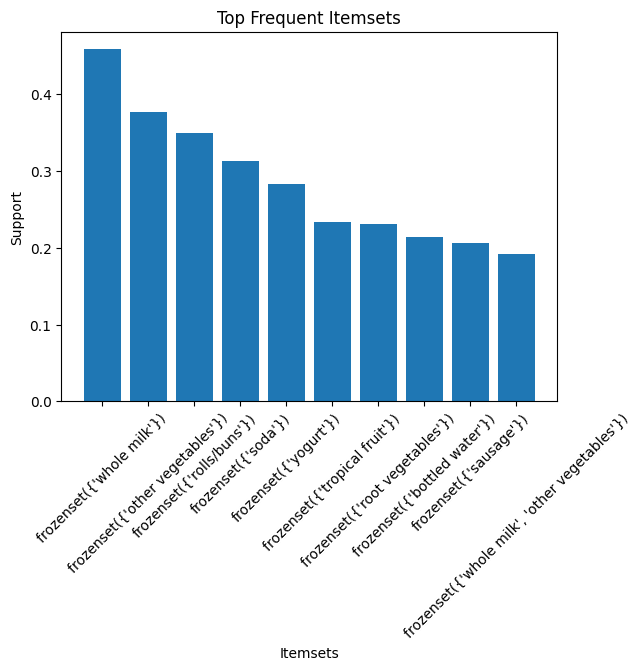

In [4]:
# Visualization 1: Bar Chart of Frequent Itemsets
top_items = frequent_itemsets.sort_values(by='support', ascending=False).head(10)

plt.bar(range(len(top_items)), top_items['support'])
plt.xticks(range(len(top_items)), top_items['itemsets'], rotation=45)
plt.title("Top Frequent Itemsets")
plt.xlabel("Itemsets")
plt.ylabel("Support")
plt.show()

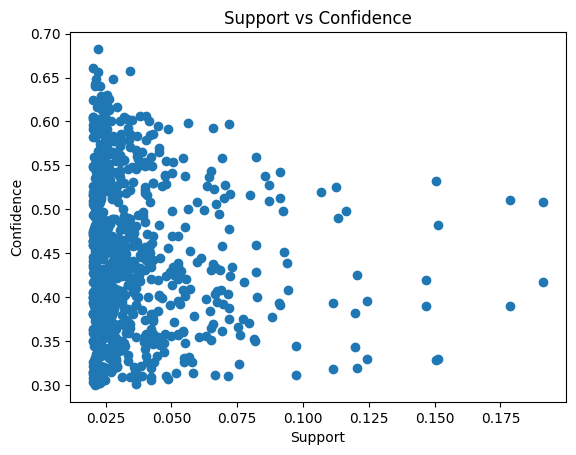

In [5]:
# Visualization 2: Support vs Confidence
plt.scatter(rules['support'], rules['confidence'])
plt.title("Support vs Confidence")
plt.xlabel("Support")
plt.ylabel("Confidence")
plt.show()

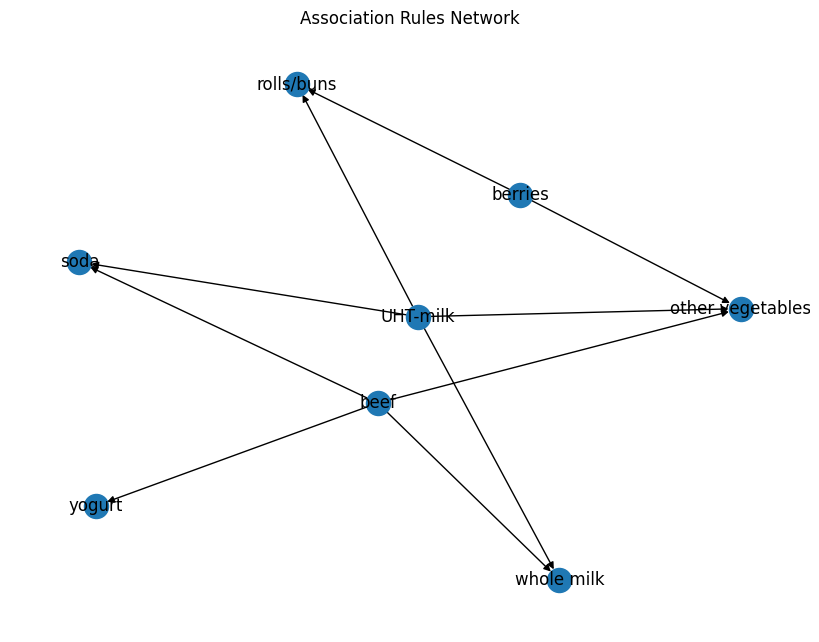

In [6]:
# Visualization 3: Network Graph
G = nx.DiGraph()

for _, row in rules.head(10).iterrows():
    for antecedent in row['antecedents']:
        for consequent in row['consequents']:
            G.add_edge(antecedent, consequent)

plt.figure(figsize=(8,6))
nx.draw(G, with_labels=True)
plt.title("Association Rules Network")
plt.show()

EXP 8 – SCENARIO 2: PCA

In [7]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris

data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)

print(df.head())

# Preprocessing
# Check missing values
print("\nMissing Values:\n", df.isnull().sum())

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
0                5.1               3.5                1.4               0.2
1                4.9               3.0                1.4               0.2
2                4.7               3.2                1.3               0.2
3                4.6               3.1                1.5               0.2
4                5.0               3.6                1.4               0.2

Missing Values:
 sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
dtype: int64


In [8]:
# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Apply PCA
pca = PCA()
X_pca = pca.fit_transform(X_scaled)


# Explained Variance
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print("\nExplained Variance Ratio:")
print(explained_variance)


Explained Variance Ratio:
[0.72962445 0.22850762 0.03668922 0.00517871]


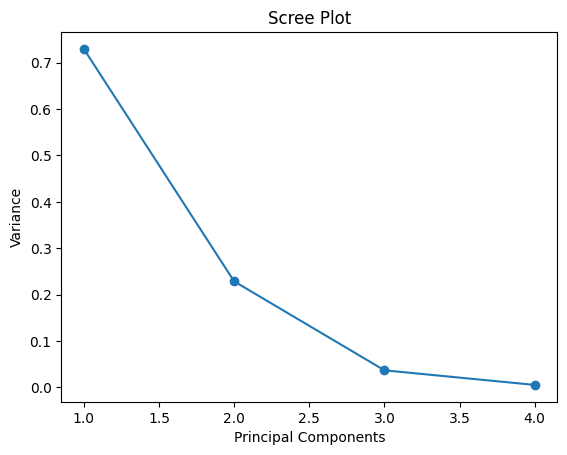

In [9]:
# Reduce to 2 Components
pca_2 = PCA(n_components=2)
X_reduced = pca_2.fit_transform(X_scaled)

# Visualization 1: Scree Plot
plt.plot(range(1, len(explained_variance)+1), explained_variance, marker='o')
plt.title("Scree Plot")
plt.xlabel("Principal Components")
plt.ylabel("Variance")
plt.show()

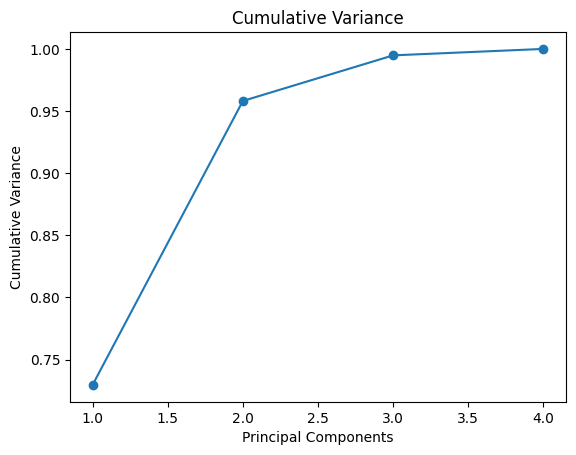

In [10]:
# Visualization 2: Cumulative Variance
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.title("Cumulative Variance")
plt.xlabel("Principal Components")
plt.ylabel("Cumulative Variance")
plt.show()

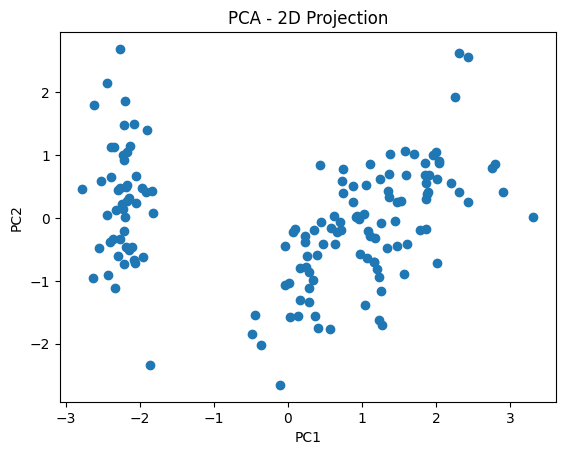

In [11]:
# Visualization 3: 2D Scatter Plot
plt.scatter(X_reduced[:, 0], X_reduced[:, 1])
plt.title("PCA - 2D Projection")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()